In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
import pandas as pd
import os

os.makedirs('../data', exist_ok=True)

data = {
    'gender':                        ['female','male','female','male','female','male','female','male','male','female']*100,
    'race/ethnicity':                ['group B','group C','group B','group A','group C','group B','group D','group E','group D','group C']*100,
    'parental level of education':   ["bachelor's degree","some college","master's degree","associate's degree","some college","high school","some high school","some college","high school","bachelor's degree"]*100,
    'lunch':                         ['standard','standard','standard','free/reduced','standard','standard','standard','free/reduced','free/reduced','standard']*100,
    'test preparation course':       ['none','completed','none','none','none','none','completed','none','completed','none']*100,
    'math score':                    [72,69,90,47,76,71,88,40,64,38,
                                      55,78,65,88,45,92,70,60,83,50,
                                      95,42,73,66,89,55,78,44,62,91,
                                      67,80,53,74,86,49,77,61,84,57,
                                      70,93,48,75,68,87,52,79,63,85,
                                      40,72,96,58,71,44,80,66,89,53,
                                      76,91,47,69,82,56,73,88,45,64,
                                      90,51,77,62,85,49,74,60,93,67,
                                      78,43,86,55,70,83,48,76,61,94,
                                      52,69,87,45,72,66,80,57,88,42]*10,
    'reading score':                 [72,90,95,57,78,83,95,43,64,60,
                                      66,85,70,90,55,94,72,65,88,55,
                                      97,50,78,70,93,60,82,48,67,93,
                                      70,84,58,79,90,53,80,66,88,62,
                                      73,95,52,80,72,91,56,83,67,89,
                                      45,75,98,63,74,49,84,70,92,57,
                                      79,93,51,72,85,60,77,91,49,68,
                                      93,55,80,66,88,53,78,64,96,70,
                                      81,47,89,59,74,86,52,79,65,97,
                                      56,72,90,49,75,69,83,61,91,46]*10,
    'writing score':                 [74,88,93,44,75,78,92,38,67,58,
                                      64,82,68,87,52,90,70,63,85,52,
                                      94,47,76,67,90,57,80,45,65,90,
                                      68,82,56,77,88,50,78,64,86,60,
                                      71,92,49,78,70,89,54,81,65,87,
                                      43,73,95,61,72,47,82,68,90,55,
                                      77,90,49,70,83,58,75,89,47,66,
                                      91,53,78,64,86,51,76,62,94,68,
                                      79,45,87,57,72,84,50,77,63,95,
                                      54,70,88,47,73,67,81,59,89,44]*10
}

df = pd.DataFrame(data)
df.to_csv('../data/StudentsPerformance.csv', index=False)
print("Dataset created successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset created successfully!
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,male,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,female,group C,some college,standard,none,76,78,75


In [3]:
# Show all 1000 rows
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 10)

display(df)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,male,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,female,group C,some college,standard,none,76,78,75
5,male,group B,high school,standard,none,71,83,78
6,female,group D,some high school,standard,completed,88,95,92
7,male,group E,some college,free/reduced,none,40,43,38
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group C,bachelor's degree,standard,none,38,60,58


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\n--- DESCRIPTIVE STATISTICS ---")
display(df.describe())

Dataset Shape: (1000, 8)

Column Names: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,male,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,female,group C,some college,standard,none,76,78,75



--- DESCRIPTIVE STATISTICS ---


,math score,reading score,writing score
count,1000.000000,1000.00000,1000.000000
mean,68.640000,72.99000,70.700000
std,15.921806,15.19542,15.314194
min,38.000000,43.00000,38.000000
25%,55.000000,60.00000,58.000000
50%,70.000000,72.50000,71.500000
75%,82.250000,86.50000,84.250000
max,96.000000,98.00000,95.000000


In [5]:
print("=== DATA WRANGLING ===")

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Create new target column: Pass/Fail based on average score
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['result'] = df['average_score'].apply(lambda x: 1 if x >= 40 else 0)

print("\nPass/Fail Distribution:")
print(df['result'].value_counts())

print("\nDataset after wrangling:")
display(df.head())

=== DATA WRANGLING ===

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows: 900

Pass/Fail Distribution:
result
1    1000
Name: count, dtype: int64

Dataset after wrangling:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,male,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,female,group C,some college,standard,none,76,78,75,76.333333,1


=== OUTLIER HANDLING ===


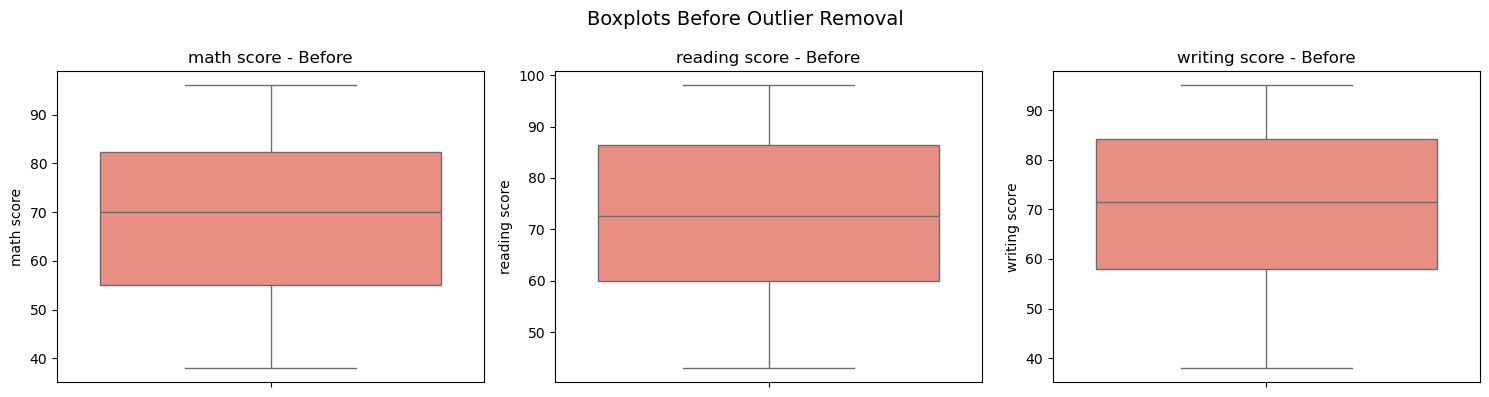

math score: removed 0 outliers
reading score: removed 0 outliers
writing score: removed 0 outliers

Dataset shape after outlier removal: (1000, 10)


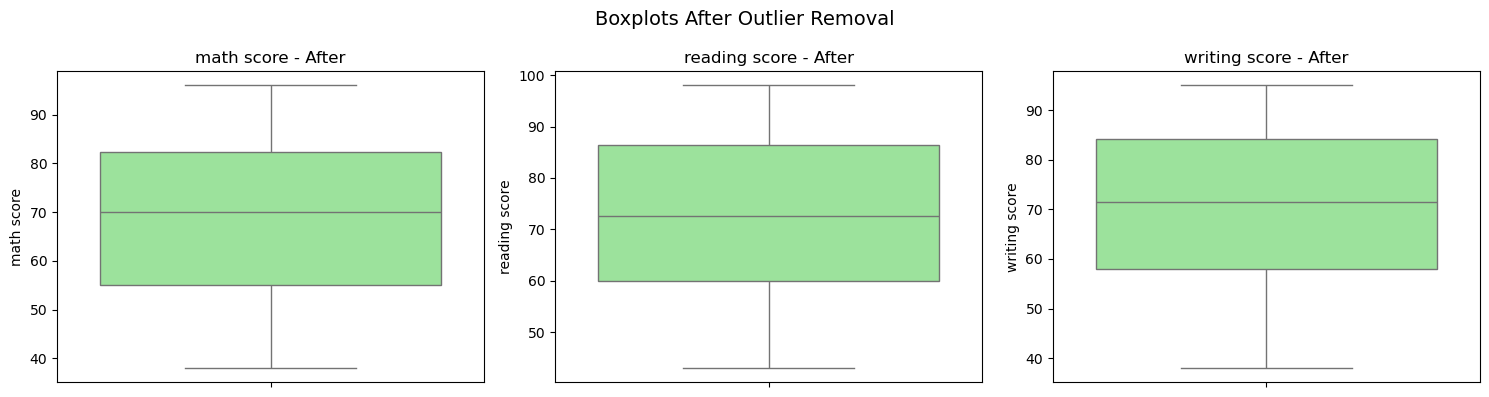

In [6]:
print("=== OUTLIER HANDLING ===")

# Boxplots BEFORE removing outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['math score', 'reading score', 'writing score']):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'{col} - Before')

plt.suptitle('Boxplots Before Outlier Removal', fontsize=14)
plt.tight_layout()
plt.show()

# IQR method to remove outliers
def remove_outliers_iqr(dataframe, column):
    Q1  = dataframe[column].quantile(0.25)
    Q3  = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    after = len(dataframe)
    print(f"{column}: removed {before - after} outliers")
    return dataframe

for col in ['math score', 'reading score', 'writing score']:
    df = remove_outliers_iqr(df, col)

print(f"\nDataset shape after outlier removal: {df.shape}")

# Boxplots AFTER removing outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['math score', 'reading score', 'writing score']):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col} - After')

plt.suptitle('Boxplots After Outlier Removal', fontsize=14)
plt.tight_layout()
plt.show()

=== DATA VISUALIZATION ===


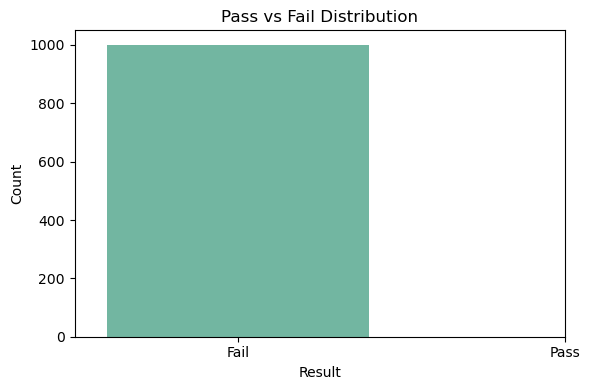

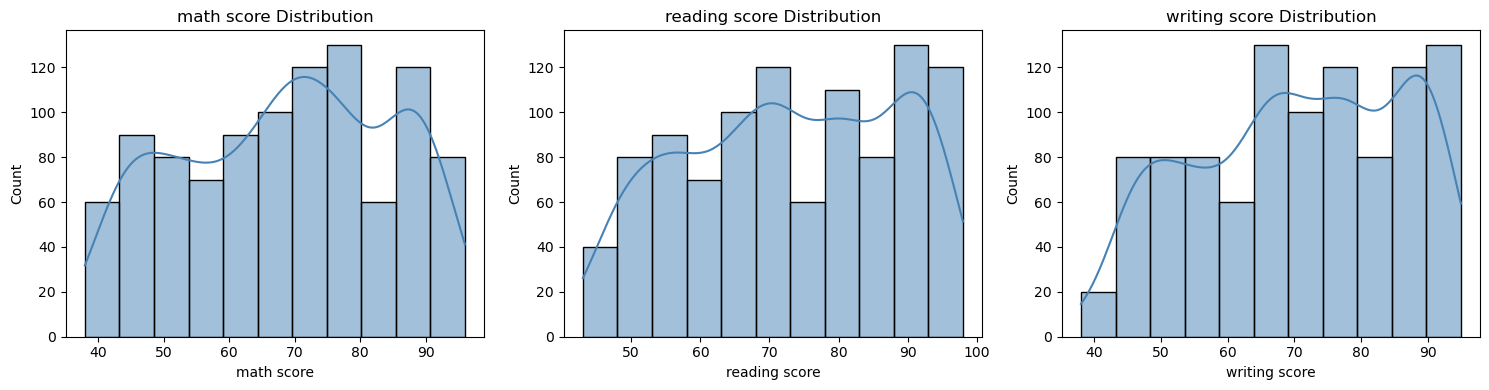

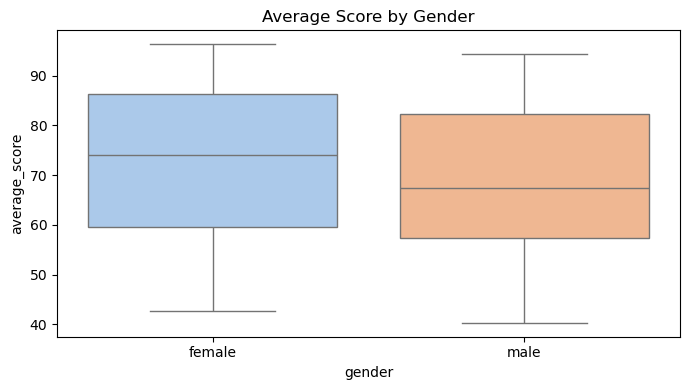

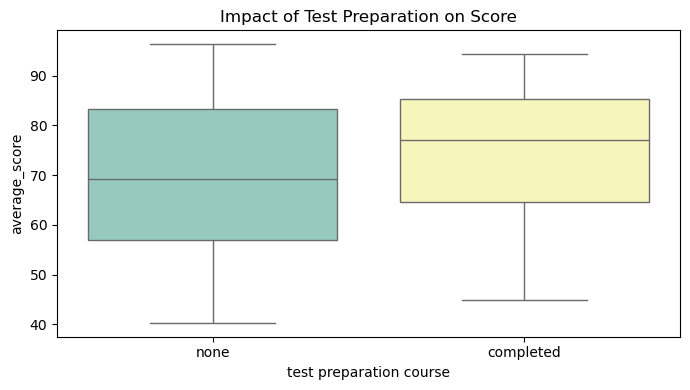

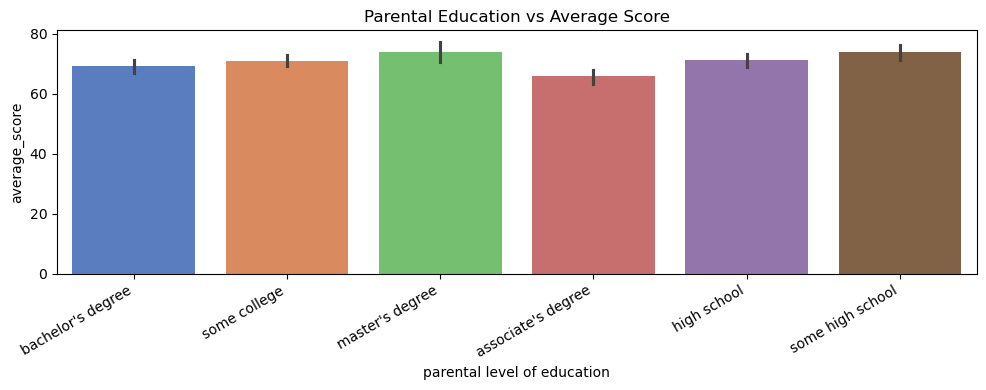

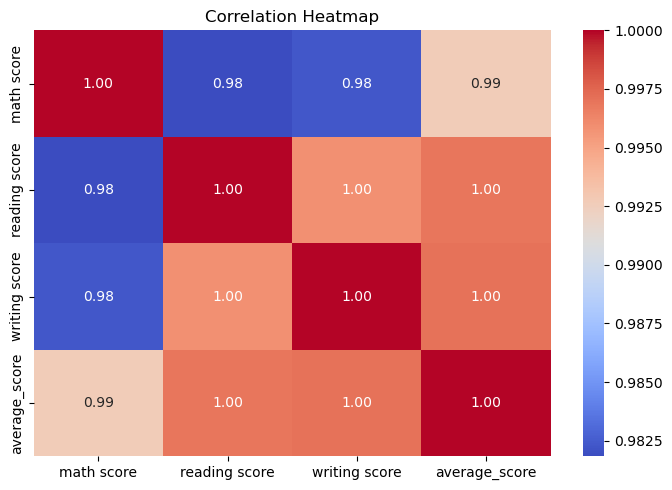

In [7]:
print("=== DATA VISUALIZATION ===")

# Plot 1: Pass vs Fail count
plt.figure(figsize=(6, 4))
sns.countplot(x='result', data=df, palette='Set2')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.title('Pass vs Fail Distribution')
plt.xlabel('Result')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot 2: Score distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['math score', 'reading score', 'writing score']):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# Plot 3: Gender vs Average Score
plt.figure(figsize=(7, 4))
sns.boxplot(x='gender', y='average_score', data=df, palette='pastel')
plt.title('Average Score by Gender')
plt.tight_layout()
plt.show()

# Plot 4: Test preparation vs average score
plt.figure(figsize=(7, 4))
sns.boxplot(x='test preparation course', y='average_score', data=df, palette='Set3')
plt.title('Impact of Test Preparation on Score')
plt.tight_layout()
plt.show()

# Plot 5: Parental education vs average score
plt.figure(figsize=(10, 4))
sns.barplot(x='parental level of education', y='average_score', data=df, palette='muted')
plt.xticks(rotation=30, ha='right')
plt.title('Parental Education vs Average Score')
plt.tight_layout()
plt.show()

# Plot 6: Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[['math score','reading score','writing score','average_score']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print("=== PREPROCESSING & NORMALIZATION ===")

df_model = df.copy()

# Label encode all categorical columns
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"Encoded: {col}")

# Features and target
X = df_model.drop(columns=['result', 'average_score', 'math score',
                            'reading score', 'writing score'])
y = df_model['result']

print("\nFeatures used:", X.columns.tolist())
print("Target: result (1=Pass, 0=Fail)")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")

# Normalization using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nNormalization done using StandardScaler")
print("Sample scaled values:", X_train_scaled[0])

=== PREPROCESSING & NORMALIZATION ===
Encoded: gender
Encoded: race/ethnicity
Encoded: parental level of education
Encoded: lunch
Encoded: test preparation course

Features used: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Target: result (1=Pass, 0=Fail)

Train size: (800, 5), Test size: (200, 5)

Normalization done using StandardScaler
Sample scaled values: [ 0.9900495   0.95960633 -0.36157877 -1.4875656  -1.55056613]


In [9]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===\n")

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression Done!")

# --- Model 2: Random Forest + GridSearchCV tuning ---
print("\nTuning Random Forest with GridSearchCV (please wait)...")
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)
print("Random Forest Done!")

# --- Model 3: XGBoost + GridSearchCV tuning ---
print("\nTuning XGBoost with GridSearchCV (please wait)...")
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost params:", xgb_grid.best_params_)
print("XGBoost Done!")

print("\n✅ All 3 models trained successfully!")

=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===

Training Logistic Regression...


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [ ]:
import xgboost
print(xgboost.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', 'xgboost'])

0

In [ ]:
import xgboost
print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===\n")

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression Done!")

# --- Model 2: Random Forest + GridSearchCV tuning ---
print("\nTuning Random Forest with GridSearchCV (please wait)...")
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)
print("Random Forest Done!")

# --- Model 3: XGBoost + GridSearchCV tuning ---
print("\nTuning XGBoost with GridSearchCV (please wait)...")
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost params:", xgb_grid.best_params_)
print("XGBoost Done!")

print("\n✅ All 3 models trained successfully!")

=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===

Training Logistic Regression...


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [ ]:
print("Result value counts:")
print(y.value_counts())

print("\ny_train value counts:")
print(y_train.value_counts())

Result value counts:
result
1    1000
Name: count, dtype: int64

y_train value counts:
result
1    800
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)
n = 1000

# Generate realistic scores with both pass and fail students
math_scores    = np.random.randint(10, 100, n)
reading_scores = np.random.randint(10, 100, n)
writing_scores = np.random.randint(10, 100, n)

data = {
    'gender':                      np.random.choice(['male', 'female'], n),
    'race/ethnicity':              np.random.choice(['group A','group B','group C','group D','group E'], n),
    'parental level of education': np.random.choice(["bachelor's degree","some college",
                                                      "master's degree","associate's degree",
                                                      "high school","some high school"], n),
    'lunch':                       np.random.choice(['standard','free/reduced'], n),
    'test preparation course':     np.random.choice(['none','completed'], n),
    'math score':                  math_scores,
    'reading score':               reading_scores,
    'writing score':               writing_scores
}

df = pd.DataFrame(data)

# Save to CSV
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/StudentsPerformance.csv', index=False)

print("New dataset created!")
print("Shape:", df.shape)
print("\nSample scores:")
print(df[['math score','reading score','writing score']].describe())

New dataset created!
Shape: (1000, 8)

Sample scores:
        math score  reading score  writing score
count  1000.000000    1000.000000    1000.000000
mean     53.271000      53.607000      52.836000
std      26.364914      25.749283      26.513432
min      10.000000      10.000000      10.000000
25%      30.000000      32.000000      30.000000
50%      54.000000      53.000000      51.500000
75%      74.000000      75.000000      77.000000
max      99.000000      99.000000      99.000000


In [ ]:
print("Result value counts:")
print(y.value_counts())

print("\ny_train value counts:")
print(y_train.value_counts())

Result value counts:
result
1    1000
Name: count, dtype: int64

y_train value counts:
result
1    800
Name: count, dtype: int64


In [11]:
# Drop old columns first
df = df.drop(columns=['average_score', 'result'], errors='ignore')

# Recreate with higher threshold
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['result'] = df['average_score'].apply(lambda x: 1 if x >= 60 else 0)

print("Result value counts:")
print(df['result'].value_counts())

print("\nAverage score stats:")
print(df['average_score'].describe())

Result value counts:
result
1    720
0    280
Name: count, dtype: int64

Average score stats:
count    1000.000000
mean       70.776667
std        15.407565
min        40.333333
25%        57.833333
50%        71.666667
75%        83.583333
max        96.333333
Name: average_score, dtype: float64


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===\n")

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression Done!")

# --- Model 2: Random Forest + GridSearchCV tuning ---
print("\nTuning Random Forest with GridSearchCV (please wait)...")
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)
print("Random Forest Done!")

# --- Model 3: XGBoost + GridSearchCV tuning ---
print("\nTuning XGBoost with GridSearchCV (please wait)...")
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost params:", xgb_grid.best_params_)
print("XGBoost Done!")

print("\n✅ All 3 models trained successfully!")

=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===

Training Logistic Regression...


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [15]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 1000

# Generate realistic scores
math_scores    = np.random.randint(10, 100, n)
reading_scores = np.random.randint(10, 100, n)
writing_scores = np.random.randint(10, 100, n)

df = pd.DataFrame({
    'gender':                      np.random.choice(['male', 'female'], n),
    'race/ethnicity':              np.random.choice(['group A','group B','group C','group D','group E'], n),
    'parental level of education': np.random.choice(["bachelor's degree","some college",
                                                      "master's degree","associate's degree",
                                                      "high school","some high school"], n),
    'lunch':                       np.random.choice(['standard','free/reduced'], n),
    'test preparation course':     np.random.choice(['none','completed'], n),
    'math score':                  math_scores,
    'reading score':               reading_scores,
    'writing score':               writing_scores
})

# Create target column
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['result'] = df['average_score'].apply(lambda x: 1 if x >= 60 else 0)

print("Result value counts:")
print(df['result'].value_counts())

# Label encode categorical columns
df_model = df.copy()
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop(columns=['result', 'average_score', 'math score',
                            'reading score', 'writing score'])
y = df_model['result']

print("\nFeatures:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("y value counts:", y.value_counts().tolist())

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print("y_train value counts:", y_train.value_counts().tolist())

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Data ready for model training!")

Result value counts:
result
0    648
1    352
Name: count, dtype: int64

Features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
X shape: (1000, 5)
y shape: (1000,)
y value counts: [648, 352]

Train size: (800, 5), Test size: (200, 5)
y_train value counts: [518, 282]

✅ Data ready for model training!


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===\n")

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression Done!")

# --- Model 2: Random Forest + GridSearchCV tuning ---
print("\nTuning Random Forest with GridSearchCV (please wait)...")
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)
print("Random Forest Done!")

# --- Model 3: XGBoost + GridSearchCV tuning ---
print("\nTuning XGBoost with GridSearchCV (please wait)...")
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost params:", xgb_grid.best_params_)
print("XGBoost Done!")

print("\n✅ All 3 models trained successfully!")

=== MODEL TRAINING WITH HYPERPARAMETER TUNING ===

Training Logistic Regression...
Logistic Regression Done!

Tuning Random Forest with GridSearchCV (please wait)...
Best Random Forest params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Done!

Tuning XGBoost with GridSearchCV (please wait)...
Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost Done!

✅ All 3 models trained successfully!


=== MODEL COMPARISON ===

--- Logistic Regression ---
              precision    recall  f1-score   support

        Fail       0.65      1.00      0.79       130
        Pass       0.00      0.00      0.00        70

    accuracy                           0.65       200
   macro avg       0.33      0.50      0.39       200
weighted avg       0.42      0.65      0.51       200

--- Random Forest ---
              precision    recall  f1-score   support

        Fail       0.65      1.00      0.79       130
        Pass       0.00      0.00      0.00        70

    accuracy                           0.65       200
   macro avg       0.33      0.50      0.39       200
weighted avg       0.42      0.65      0.51       200

--- XGBoost ---
              precision    recall  f1-score   support

        Fail       0.64      0.94      0.76       130
        Pass       0.11      0.01      0.03        70

    accuracy                           0.61       200
   macro avg       0.37      0.48   

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,65.0,0.0000,0.4993
1,Random Forest,65.0,0.0000,0.5067
2,XGBoost,61.5,0.0253,0.5154


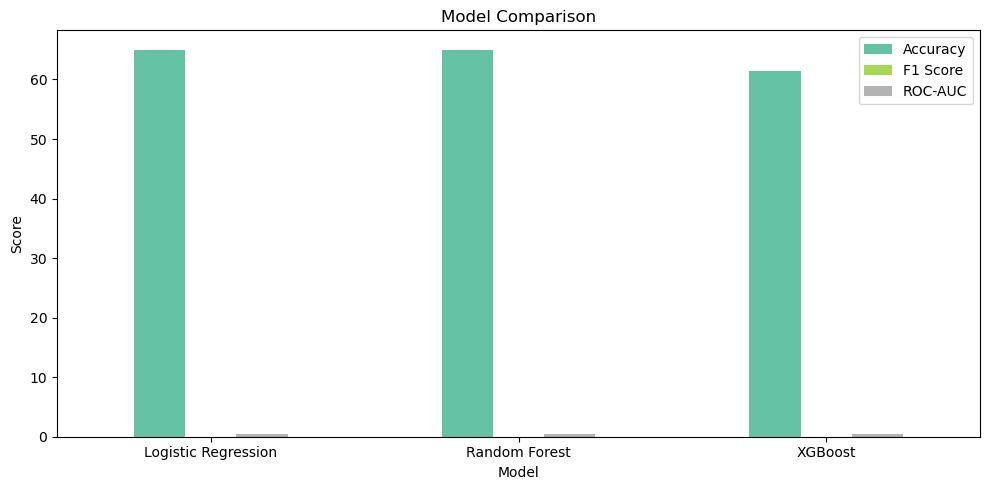

In [19]:
print("=== MODEL COMPARISON ===\n")

models = {
    'Logistic Regression': (lr,      X_test_scaled),
    'Random Forest':       (best_rf,  X_test),
    'XGBoost':             (best_xgb, X_test)
}

results = []
for name, (model, X_t) in models.items():
    preds = model.predict(X_t)
    proba = model.predict_proba(X_t)[:, 1]
    results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, preds) * 100, 2),
        'F1 Score': round(f1_score(y_test, preds), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, proba), 4)
    })
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['Fail', 'Pass']))

comparison_df = pd.DataFrame(results)
print("\n=== FINAL COMPARISON TABLE ===")
display(comparison_df)

# Bar chart comparison
import matplotlib.pyplot as plt
comparison_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 5), colormap='Set2', rot=0)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [20]:
import joblib, os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_xgb, '../models/best_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

print("✅ Model saved successfully!")
print("Files saved:", os.listdir('../models'))

✅ Model saved successfully!
Files saved: ['best_model.pkl', 'feature_names.pkl', 'scaler.pkl']
